In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the raw dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Saving Electric_Vehicle_Population_Data.csv to Electric_Vehicle_Population_Data.csv
Dataset loaded successfully.
Rows    : 270,262
Columns : 16


In [ ]:
print("DATASET OVERVIEW")
display(df.head())

print("\nDataset Shape:", df.shape)

DATASET OVERVIEW


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE8L,Thurston,Tumwater,WA,98501.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,35.0,124633715,POINT (-122.89165 47.03954),PUGET SOUND ENERGY INC,5.306701e+10
1,5YJXCAE2XJ,Snohomish,Bothell,WA,98021.0,2018,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,1.0,474826075,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJ3E1EBXK,King,Kent,WA,98031.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,47.0,280307233,POINT (-122.17743 47.41185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7SAYGDEE4T,King,Issaquah,WA,98027.0,2026,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,41.0,280786565,POINT (-122.03439 47.5301),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,WAUUPBFF9G,King,Seattle,WA,98103.0,2016,AUDI,A3,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,43.0,198988891,POINT (-122.35436 47.67596),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10



Dataset Shape: (270262, 16)


##EV Market Composition

How is the EV market distributed between Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs)?

In [ ]:
ev_type = df["Electric Vehicle Type"].value_counts()

print(ev_type)

Electric Vehicle Type
Battery Electric Vehicle (BEV)            215859
Plug-in Hybrid Electric Vehicle (PHEV)     54403
Name: count, dtype: int64


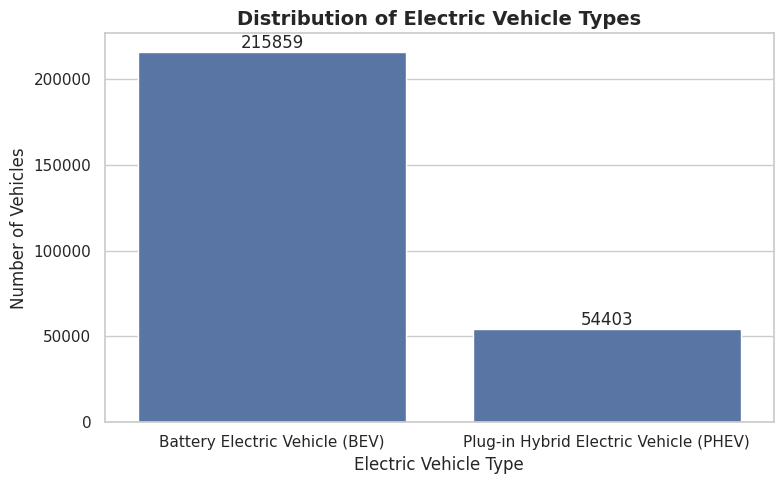

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Electric Vehicle Type",
    order=ev_type.index
)

plt.title("Distribution of Electric Vehicle Types", fontsize=14, fontweight="bold")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Number of Vehicles")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

### Business Insight

The analysis shows that **Battery Electric Vehicles (BEVs) dominate the EV market**, accounting for approximately **79.9%** of all registered electric vehicles, while **Plug-in Hybrid Electric Vehicles (PHEVs)** make up around **20.1%**.

This indicates that consumers are increasingly preferring fully electric vehicles over hybrid alternatives. The high proportion of BEVs also suggests a growing demand for public charging infrastructure, as BEVs rely entirely on electric charging compared to PHEVs, which can also operate using conventional fuel.

##EV Adoption by Model Year
How has EV adoption changed over the years?

This analysis helps us identify whether EV registrations are increasing, declining, or remaining stable over different model years.

In [ ]:
yearly_adoption = (
    df.groupby("Model Year")
      .size()
      .reset_index(name="EV Registrations")
      .sort_values("Model Year")
)

display(yearly_adoption)

,Model Year,EV Registrations
0,1999,2
1,2000,8
2,2002,1
3,2003,1
4,2008,20
5,2010,23
6,2011,603
7,2012,1402
8,2013,3989
9,2014,3223


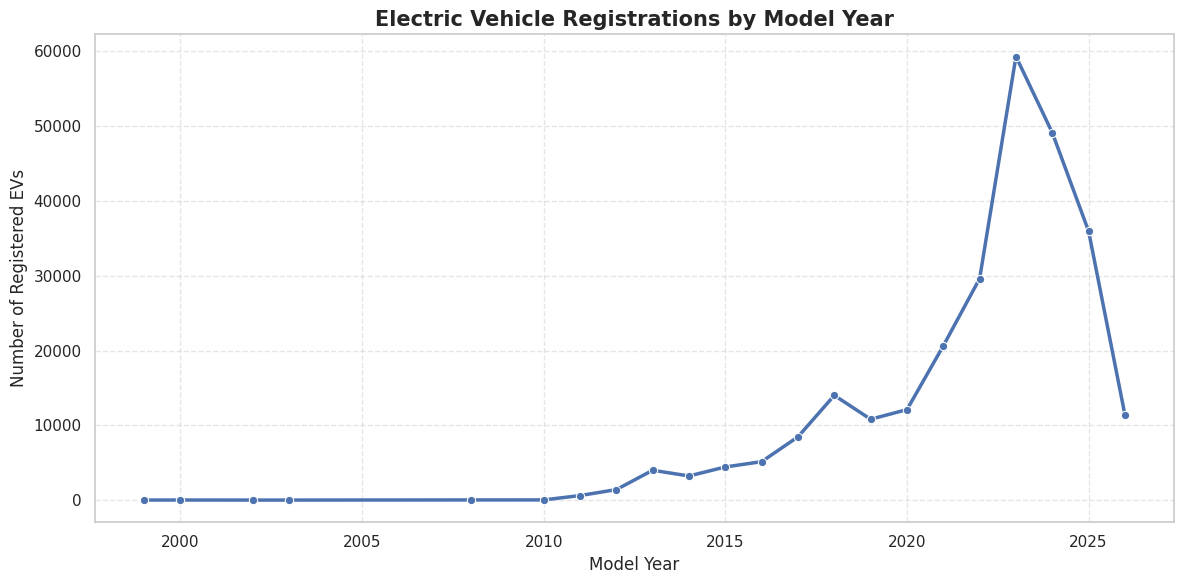

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=yearly_adoption,
    x="Model Year",
    y="EV Registrations",
    marker="o",
    linewidth=2.5
)

plt.title("Electric Vehicle Registrations by Model Year",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Business Insight

The number of registered electric vehicles has increased significantly over recent model years, indicating strong growth in EV adoption.

- EV registrations remained relatively low before **2017**.
- A noticeable increase began from **2018 onwards**, reflecting growing consumer interest and wider market availability.
- **2023 recorded the highest number of EV registrations (59,324 vehicles)**, making it the peak adoption year in the dataset.
- Registrations decline for **2024–2026**, which is expected because newer model years are still being registered and the dataset may not yet contain complete records for those years.

Overall, the trend demonstrates a rapid expansion of the electric vehicle market over the last decade.

##Geographic Analysis
3A : Which geographic regions have the highest EV adoption?











In [ ]:
# Top 15 Counties by EV Registrations
top_counties = (
    df["County"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_counties.columns = ["County", "EV Registrations"]

print(top_counties)

       County  EV Registrations
0        King            133903
1   Snohomish             33531
2      Pierce             22213
3       Clark             16553
4    Thurston              9852
5      Kitsap              9057
6     Spokane              7593
7     Whatcom              6620
8      Benton              3792
9      Skagit              3166
10     Island              2962
11     Yakima              1864
12     Chelan              1691
13    Clallam              1647
14  Jefferson              1435


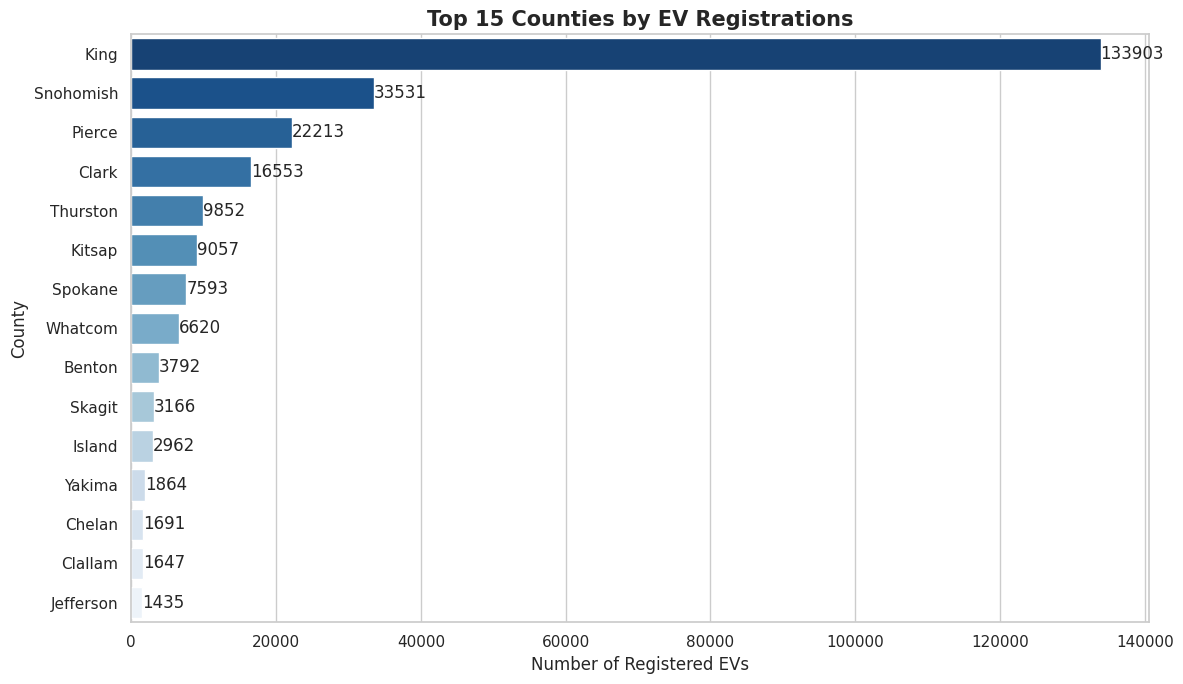

In [ ]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_counties,
    x="EV Registrations",
    y="County",
    palette="Blues_r"
)

plt.title("Top 15 Counties by EV Registrations",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Registered EVs")
plt.ylabel("County")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Business Insight

The county-wise analysis reveals that **King County** has the highest concentration of electric vehicle registrations, with **133,903 registered EVs**, significantly exceeding all other counties. **Snohomish** and **Pierce** counties rank second and third, respectively.

This indicates that EV adoption is highly concentrated in a few counties rather than being evenly distributed across the state. These high-adoption regions are likely to require greater investment in public charging infrastructure, maintenance facilities, and grid capacity to support the growing number of electric vehicles.

3B : Which cities have the highest EV adoption?

In [ ]:

# Top 15 Cities by EV Registrations


top_cities = (
    df["City"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_cities.columns = ["City", "EV Registrations"]

print(top_cities)

          City  EV Registrations
0      Seattle             42125
1     Bellevue             13203
2    Vancouver             10047
3      Redmond              9321
4      Bothell              8908
5     Kirkland              7677
6    Sammamish              7551
7       Renton              7423
8      Olympia              6325
9       Tacoma              5929
10        Kent              4607
11     Spokane              4507
12  Bellingham              4493
13    Lynnwood              4400
14     Everett              4250


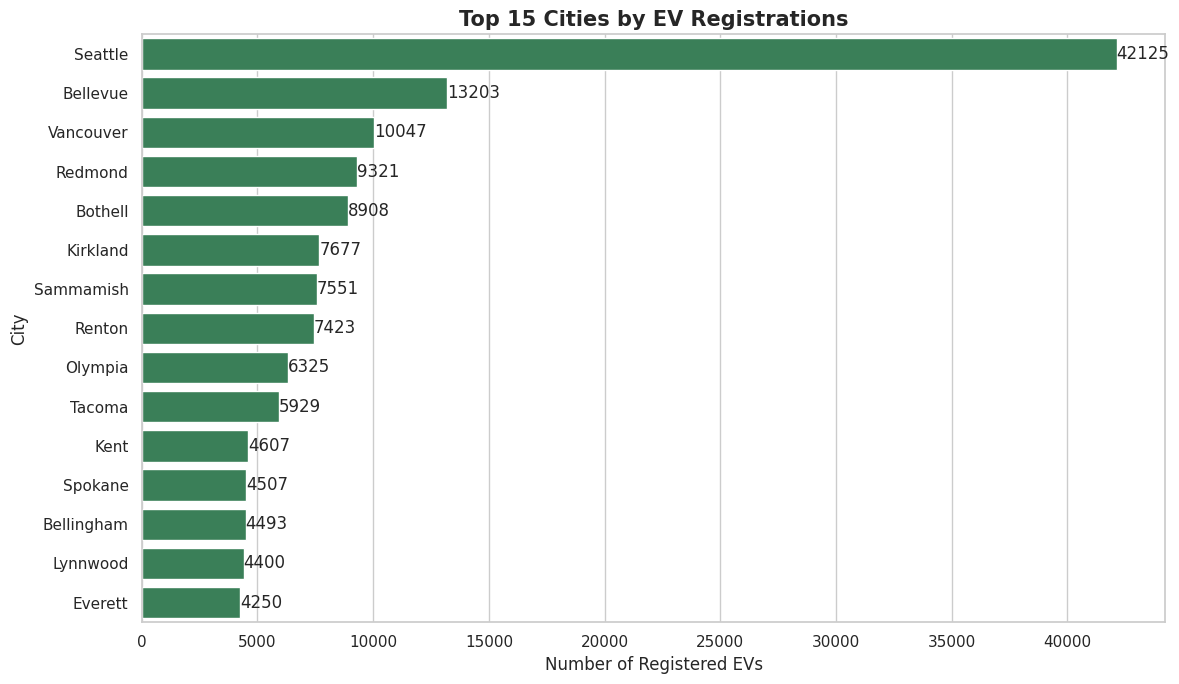

In [ ]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_cities,
    x="EV Registrations",
    y="City",
    color="seagreen"
)

plt.title("Top 15 Cities by EV Registrations",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Registered EVs")
plt.ylabel("City")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Business Insight

The city-wise analysis shows that **Seattle** has the highest number of registered electric vehicles, with **42,125 registrations**, followed by **Bellevue (13,203)** and **Vancouver (10,047)**.

The results indicate that EV adoption is concentrated in major urban areas, where population density, charging infrastructure, and consumer awareness are generally higher. These cities represent key locations for expanding EV charging networks, dealership services, and public policies promoting sustainable transportation.

##Manufacturer Analysis
Which manufacturers dominate the EV market?
Which companies have the largest market share?

In [ ]:
# Top 15 EV Manufacturers


top_makes = (
    df["Make"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_makes.columns = ["Manufacturer", "EV Registrations"]
print(top_makes)

     Manufacturer  EV Registrations
0           TESLA            111049
1       CHEVROLET             19032
2          NISSAN             15963
3            FORD             14819
4             KIA             13470
5          TOYOTA             11159
6             BMW             11036
7         HYUNDAI              9651
8          RIVIAN              8475
9      VOLKSWAGEN              7358
10          VOLVO              7021
11           JEEP              6856
12           AUDI              5788
13       CHRYSLER              3882
14  MERCEDES-BENZ              3222


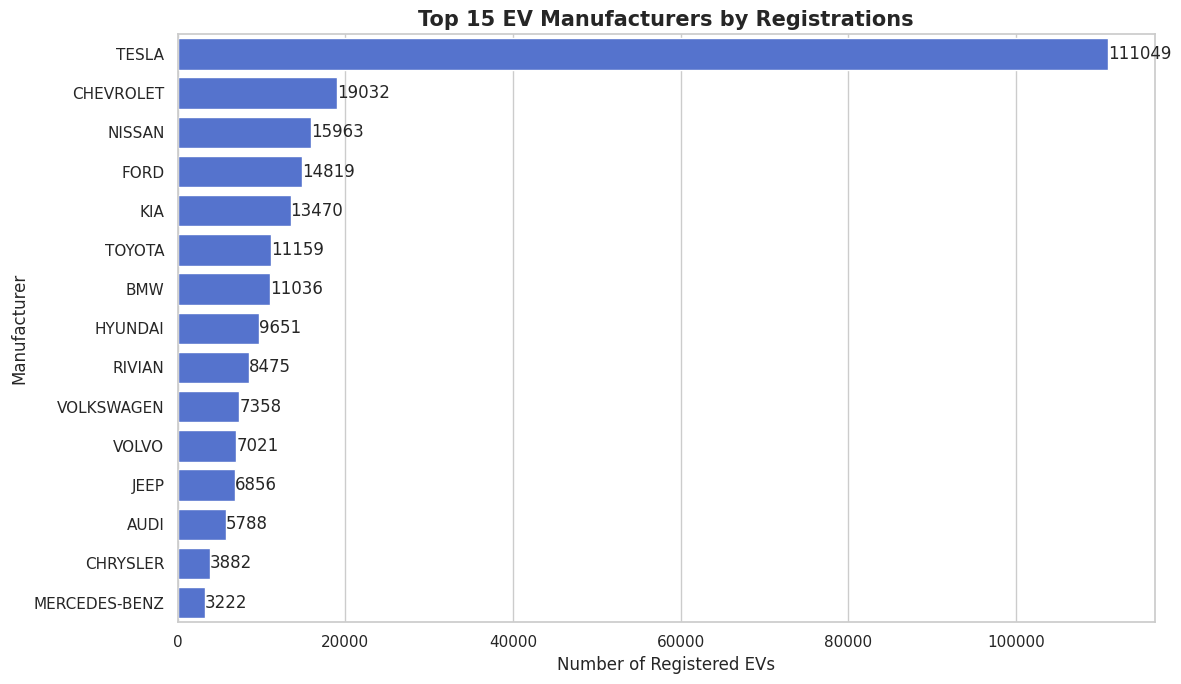

In [ ]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_makes,
    x="EV Registrations",
    y="Manufacturer",
    color="royalblue"
)

plt.title("Top 15 EV Manufacturers by Registrations",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Registered EVs")
plt.ylabel("Manufacturer")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Business Insight

The manufacturer-wise analysis reveals that **Tesla** is the clear market leader with **111,049 registered electric vehicles**, significantly outperforming all other manufacturers. **Chevrolet**, **Nissan**, and **Ford** follow but with considerably fewer registrations.

This indicates that the EV market is highly concentrated around Tesla, reflecting its strong market presence, broad product portfolio, and high consumer adoption. The presence of both established automotive manufacturers (Ford, Toyota, BMW) and newer EV-focused companies (Tesla, Rivian) highlights the increasing competitiveness of the electric vehicle market.

##Model Analysis
Which EV models are the most popular among consumers?

In [ ]:
# Top 20 EV Models


top_models = (
    df["Model"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_models.columns = ["Model", "EV Registrations"]

print(top_models)

                 Model  EV Registrations
0              MODEL Y             57335
1              MODEL 3             37413
2                 LEAF             13503
3              MODEL S              7758
4              BOLT EV              7708
5              MODEL X              6747
6       MUSTANG MACH-E              6155
7                 ID.4              5958
8              IONIQ 5              5490
9             WRANGLER              4949
10                 R1S              4817
11   RAV4 PRIME (PHEV)              4537
12                VOLT              4524
13                NIRO              4419
14               F-150              3950
15            PACIFICA              3882
16  PRIUS PRIME (PHEV)              3849
17                 EV6              3722
18                  X5              3390
19            BOLT EUV              2903


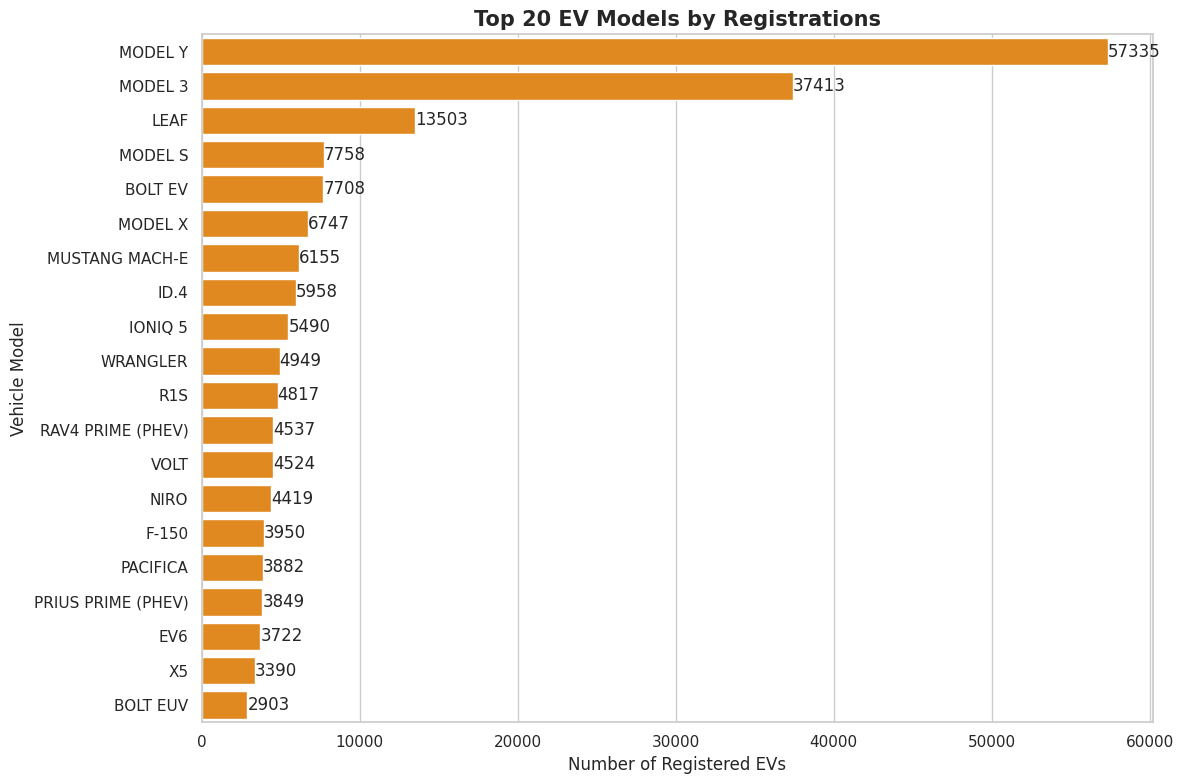

In [ ]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=top_models,
    x="EV Registrations",
    y="Model",
    color="darkorange"
)

plt.title("Top 20 EV Models by Registrations",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Registered EVs")
plt.ylabel("Vehicle Model")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Business Insight

The model-wise analysis indicates that **Tesla Model Y** is the most registered electric vehicle with **57,335 registrations**, followed by **Tesla Model 3** with **37,413 registrations**. The **Nissan Leaf** ranks third, making it one of the most widely adopted non-Tesla electric vehicles.

The popularity of multiple Tesla models reflects strong consumer preference for Tesla's product lineup. At the same time, the presence of models such as the **Chevrolet Bolt EV**, **Ford Mustang Mach-E**, **Volkswagen ID.4**, and **Hyundai IONIQ 5** highlights increasing competition among manufacturers in the EV market.

##Electric Range Analysis
What is the distribution of electric range?

How many vehicles have 0 electric range?

Are there any outliers?

Do we need preprocessing?

In [ ]:
print("Electric Range Summary Statistics")
print(df["Electric Range"].describe())

zero_range = (df["Electric Range"] == 0).sum()

print(f"\nVehicles with Zero Electric Range : {zero_range:,}")

print(f"Percentage : {(zero_range/len(df))*100:.2f}%")

Electric Range Summary Statistics
count    270257.000000
mean         40.386332
std          79.342202
min           0.000000
25%           0.000000
50%           0.000000
75%          33.000000
max         337.000000
Name: Electric Range, dtype: float64

Vehicles with Zero Electric Range : 169,872
Percentage : 62.85%


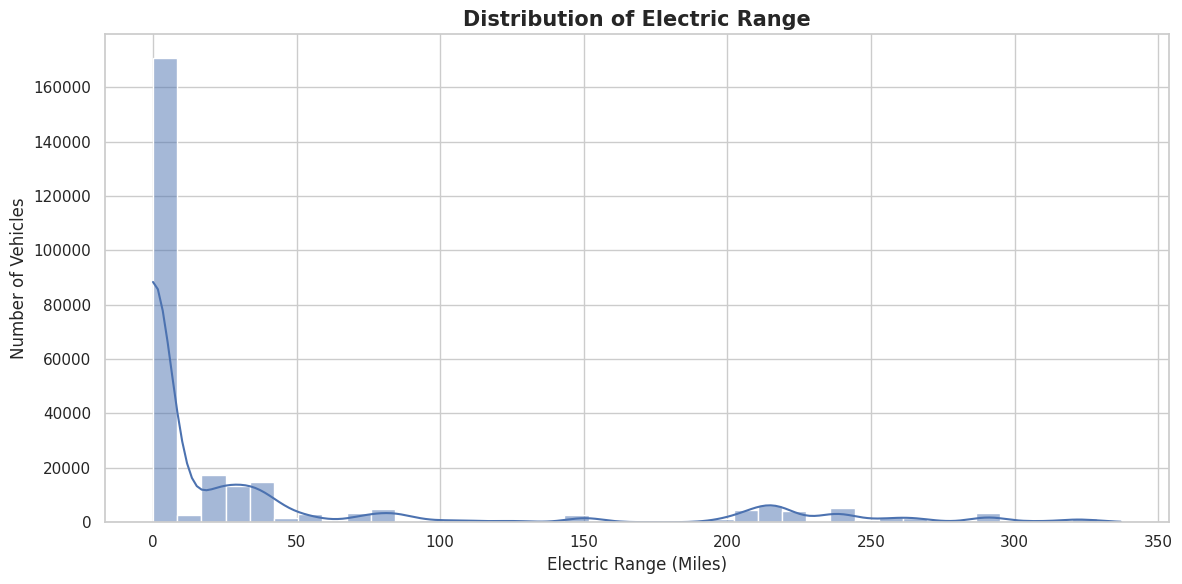

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Electric Range",
    bins=40,
    kde=True
)

plt.title("Distribution of Electric Range",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Electric Range (Miles)")
plt.ylabel("Number of Vehicles")

plt.tight_layout()
plt.show()

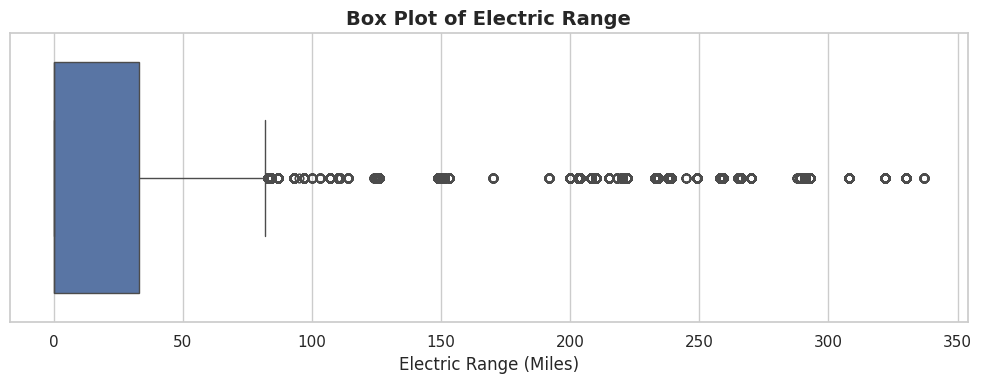

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["Electric Range"]
)

plt.title("Box Plot of Electric Range",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Electric Range (Miles)")

plt.tight_layout()
plt.show()

### Business Insight

The electric range distribution is highly skewed, with **62.85% of vehicles reporting an electric range of 0 miles**. This results in a median electric range of **0 miles**, indicating that zero values dominate the dataset.

The histogram also shows distinct groups of vehicles with moderate electric ranges (approximately 20–40 miles) and higher ranges (200–300 miles), reflecting differences between various EV technologies and generations.

Although the box plot identifies several high-range observations as statistical outliers, these values are likely to represent legitimate long-range electric vehicles rather than erroneous data. Therefore, they will be retained during preprocessing.

The large number of zero electric range values requires further investigation during data preprocessing to determine whether they represent true zero ranges or unavailable electric range information.

##CAFV Eligibility Analysis
How are vehicles distributed across different CAFV eligibility categories?

In [ ]:
cafv_counts = (
    df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
    .value_counts()
    .reset_index()
)

cafv_counts.columns = ["CAFV Eligibility", "Vehicle Count"]

print(cafv_counts)

                                    CAFV Eligibility  Vehicle Count
0  Eligibility unknown as battery range has not b...         169872
1            Clean Alternative Fuel Vehicle Eligible          76360
2              Not eligible due to low battery range          24030


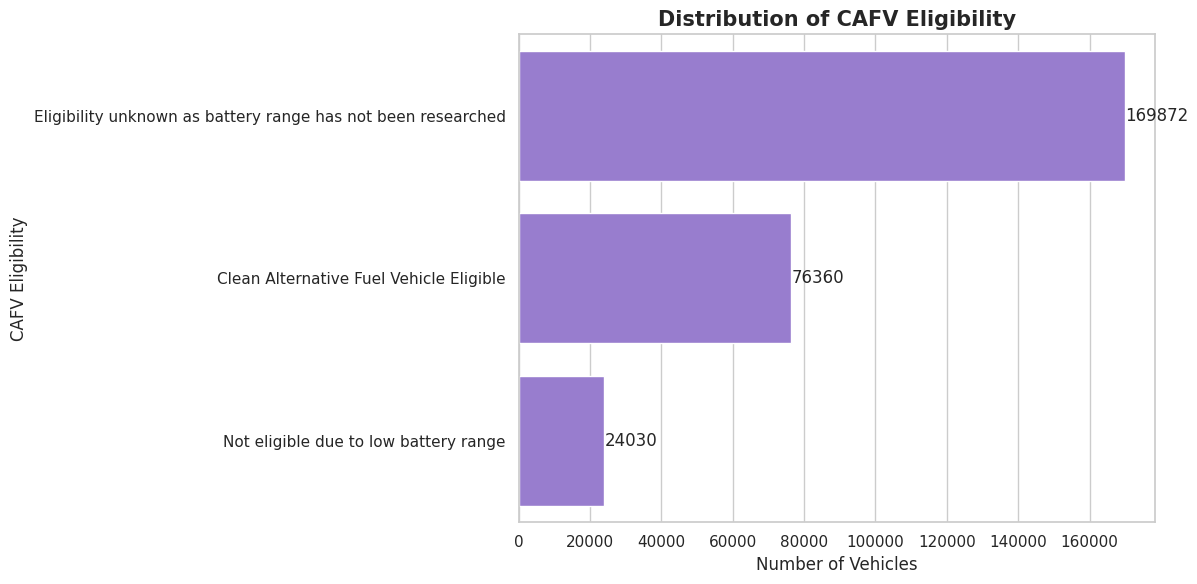

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=cafv_counts,
    x="Vehicle Count",
    y="CAFV Eligibility",
    color="mediumpurple"
)

plt.title("Distribution of CAFV Eligibility",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Vehicles")
plt.ylabel("CAFV Eligibility")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

In [ ]:
eligibility_by_type = pd.crosstab(
    df["Electric Vehicle Type"],
    df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
)

display(eligibility_by_type)

Clean Alternative Fuel Vehicle (CAFV) Eligibility,Clean Alternative Fuel Vehicle Eligible,Eligibility unknown as battery range has not been researched,Not eligible due to low battery range
Electric Vehicle Type,,,
Battery Electric Vehicle (BEV),45979,169872,8
Plug-in Hybrid Electric Vehicle (PHEV),30381,0,24022


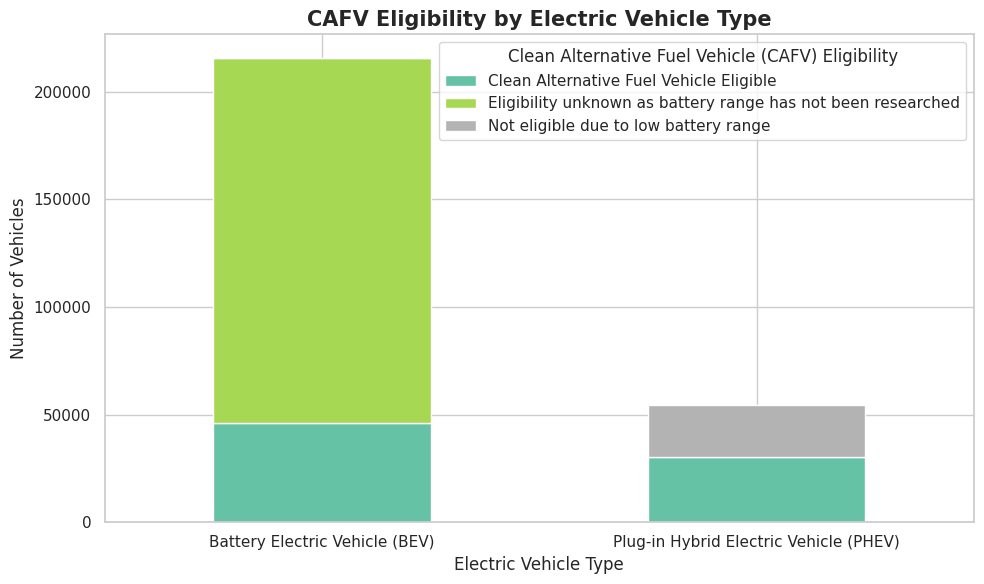

In [ ]:
eligibility_by_type.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Set2"
)

plt.title("CAFV Eligibility by Electric Vehicle Type",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Electric Vehicle Type")
plt.ylabel("Number of Vehicles")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insight

The CAFV eligibility analysis shows that the largest category is **"Eligibility Unknown"**, representing **169,872 vehicles**, followed by **76,360 CAFV-eligible vehicles** and **24,030 vehicles that are not eligible**.

When analyzed by vehicle type, almost all **"Eligibility Unknown"** records belong to **Battery Electric Vehicles (BEVs)**, while **Plug-in Hybrid Electric Vehicles (PHEVs)** are primarily classified as either eligible or not eligible.

This finding suggests that the large number of unknown eligibility records is likely due to unavailable or unverified battery range information rather than actual vehicle characteristics. These records should therefore be handled carefully during data preprocessing instead of being removed.

##Relationship Analysis
Which manufacturers provide vehicles with the highest average electric range?

In [ ]:
avg_range_make = (
    df.groupby("Make")["Electric Range"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

avg_range_make.columns = ["Manufacturer", "Average Electric Range"]

print(avg_range_make)

           Manufacturer  Average Electric Range
0                JAGUAR              178.100000
1  WHEEGO ELECTRIC CARS              100.000000
2                 TH!NK              100.000000
3             CHEVROLET               79.141709
4                  FIAT               74.274533
5                NISSAN               64.576207
6                 SMART               61.750000
7        AZURE DYNAMICS               56.000000
8                 TESLA               53.120082
9               PORSCHE               49.699374


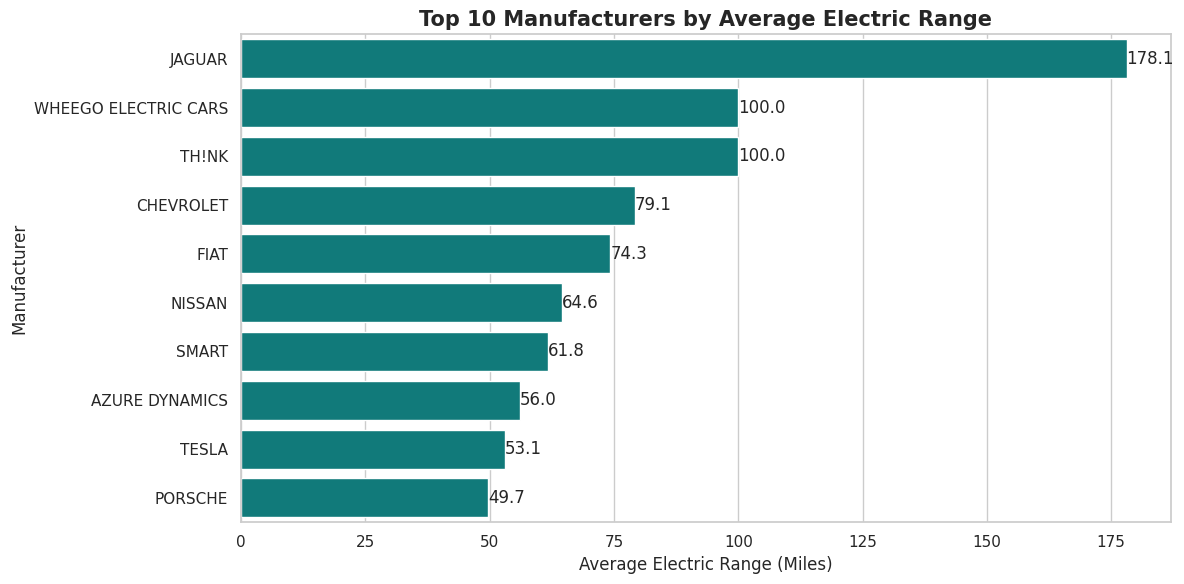

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=avg_range_make,
    x="Average Electric Range",
    y="Manufacturer",
    color="darkcyan"
)

plt.title("Top 10 Manufacturers by Average Electric Range",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Average Electric Range (Miles)")
plt.ylabel("Manufacturer")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

### Business Insight

The manufacturer-wise electric range analysis shows that **Jaguar** has the highest average electric range among the manufacturers in the dataset, followed by **Chevrolet**, **Fiat**, **Nissan**, and **Tesla** among the major manufacturers.

The results indicate that electric range varies considerably across manufacturers, reflecting differences in battery technology, vehicle segments, and model portfolios. While some manufacturers achieve higher average ranges, these values should be interpreted alongside the number of registered vehicles, as manufacturers with very few vehicles may have less representative averages.

Overall, the analysis demonstrates that vehicle range is influenced by manufacturer-specific design and technology, making electric range an important feature for further analysis and feature engineering.

# EDA Summary

## Key Findings

1. **Battery Electric Vehicles (BEVs)** account for nearly **80%** of all registered electric vehicles, indicating strong market preference for fully electric vehicles.

2. EV registrations have increased significantly over recent years, with **2023 recording the highest number of registrations**, reflecting rapid growth in EV adoption.

3. EV ownership is concentrated in a few geographic regions. **King County** and **Seattle** lead the state in electric vehicle registrations, suggesting these regions require continued investment in charging infrastructure and EV-related services.

4. **Tesla** dominates the market with the highest number of registered vehicles, while **Model Y** and **Model 3** are the most popular electric vehicle models.

5. Electric range distribution is highly skewed, with **62.85%** of vehicles reporting an electric range of **0 miles**. This exactly matches the number of vehicles classified as **"CAFV Eligibility Unknown"**, indicating that many zero values likely represent unavailable battery range information rather than actual zero-mile electric range.

6. CAFV eligibility differs across vehicle types, with most **Eligibility Unknown** records belonging to Battery Electric Vehicles (BEVs), while Plug-in Hybrid Electric Vehicles (PHEVs) are predominantly classified as either eligible or not eligible.

7. Average electric range varies across manufacturers, highlighting differences in battery technology and vehicle design. These differences make electric range an important feature for further analysis.

## Conclusion

The exploratory data analysis provides a comprehensive understanding of electric vehicle adoption patterns across vehicle types, model years, geographic regions, manufacturers, and vehicle models. The analysis also identifies key data quality issues, particularly regarding electric range and CAFV eligibility, which will be addressed during the data preprocessing and feature engineering stage. These insights establish a strong foundation for building a reliable, modeling-ready dataset.